<a href="https://colab.research.google.com/github/PreethamHD/DP-MMFL/blob/main/notebooks/05_image_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -q redivis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 820.4/820.4 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.3/408.3 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 93.9 MB/s eta 0:00:00


In [6]:
import redivis
from io import BytesIO
from PIL import Image

# Connect to the CheXpert Plus PNG table
table = redivis.table("aimi.chexpert_plus:5yyj:v1_0.png_train:s6cj")

# Download a sample frontal chest X-ray
png_path = "patient00001/study1/view1_frontal.png"
file = table.file(png_path)
data = file.read(as_text=False)

# Load as 8-bit grayscale
image = Image.open(BytesIO(data)).convert("L")

print(f"Loaded: {png_path}")
print("Original size (W, H):", image.size)
print("Original mode:       ", image.mode)

Please visit the URL below to authenticate with your Redivis account:
https://redivis.com/oauth/authorize?user_code=5e7d10f38532e6b630cc218e0909adec
Loaded: patient00001/study1/view1_frontal.png
Original size (W, H): (3408, 2800)
Original mode:        L


In [2]:
%%writefile /content/DP-MMFL/src/dp_mmfl/data/image_transforms.py
from torchvision import transforms

IMAGE_SIZE = 224
RESIZE_SIZE = 256

def get_train_transforms():
    """
    Image transformations used during model training.
    Includes random cropping, channel replication, and ImageNet normalization.
    """
    return transforms.Compose([
        transforms.Resize(RESIZE_SIZE, antialias=True),
        transforms.RandomCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

def get_eval_transforms():
    """
    Deterministic transformations used for validation and evaluation.
    Includes center cropping, channel replication, and ImageNet normalization.
    """
    return transforms.Compose([
        transforms.Resize(RESIZE_SIZE, antialias=True),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

Writing /content/DP-MMFL/src/dp_mmfl/data/image_transforms.py


In [3]:
from pathlib import Path
import sys
import os
import torch
import torchvision
from google.colab import drive

# 1. Ensure Drive is mounted
if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")

# 2. Add src to Python path
REPO_SRC = "/content/DP-MMFL/src"
if REPO_SRC not in sys.path:
    sys.path.insert(0, REPO_SRC)

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

# 3. Import and print transform definitions
from dp_mmfl.data.image_transforms import (
    get_train_transforms,
    get_eval_transforms,
)

train_transform = get_train_transforms()
eval_transform = get_eval_transforms()

print("\n--- Training Pipeline ---")
print(train_transform)

print("\n--- Evaluation Pipeline ---")
print(eval_transform)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128

--- Training Pipeline ---
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

--- Evaluation Pipeline ---
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [7]:
import redivis
from io import BytesIO
from PIL import Image

# Connect to the CheXpert Plus PNG table
table = redivis.table("aimi.chexpert_plus:5yyj:v1_0.png_train:s6cj")

# Download a sample frontal chest X-ray
png_path = "patient00001/study1/view1_frontal.png"
file = table.file(png_path)
data = file.read(as_text=False)

# Load as 8-bit grayscale
image = Image.open(BytesIO(data)).convert("L")

print(f"Loaded: {png_path}")
print("Original size (W, H):", image.size)
print("Original mode:       ", image.mode)

Loaded: patient00001/study1/view1_frontal.png
Original size (W, H): (3408, 2800)
Original mode:        L


In [8]:
processed = eval_transform(image)

print("--- Processed Tensor Metrics ---")
print("Shape: ", processed.shape)
print("Dtype: ", processed.dtype)
print("Min:   ", round(processed.min().item(), 4))
print("Max:   ", round(processed.max().item(), 4))
print("Mean:  ", round(processed.mean().item(), 4))
print("Std:   ", round(processed.std().item(), 4))

assert processed.shape == torch.Size([3, 224, 224]), f"Unexpected shape: {processed.shape}"

--- Processed Tensor Metrics ---
Shape:  torch.Size([3, 224, 224])
Dtype:  torch.float32
Min:    -2.0665
Max:    2.518
Mean:   0.256
Std:    1.2448


In [9]:
diff_0_1 = torch.abs(processed[0] - processed[1]).max().item()
diff_1_2 = torch.abs(processed[1] - processed[2]).max().item()

print(f"Max difference between Channel 0 and 1: {diff_0_1}")
print(f"Max difference between Channel 1 and 2: {diff_1_2}")

assert diff_0_1 == 0.0, "Channel 0 and 1 are not identical!"
assert diff_1_2 == 0.0, "Channel 1 and 2 are not identical!"
print("Channel parity test passed: 3-channel replication confirmed.")

Max difference between Channel 0 and 1: 0.1769871711730957
Max difference between Channel 1 and 2: 0.23103642463684082


AssertionError: Channel 0 and 1 are not identical!

In [10]:
from torchvision import transforms

# Transform up to Grayscale replication without normalization
to_3channel = transforms.Compose([
    transforms.Resize(256, antialias=True),
    transforms.CenterCrop(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

raw_3ch = to_3channel(image)

diff_raw_0_1 = torch.abs(raw_3ch[0] - raw_3ch[1]).max().item()
diff_raw_1_2 = torch.abs(raw_3ch[1] - raw_3ch[2]).max().item()

print(f"Pre-norm diff Channel 0 vs 1: {diff_raw_0_1}")
print(f"Pre-norm diff Channel 1 vs 2: {diff_raw_1_2}")

assert diff_raw_0_1 == 0.0, "Raw channels before normalization are not identical!"
assert diff_raw_1_2 == 0.0, "Raw channels before normalization are not identical!"
print("Pre-normalization channel replication verified: R == G == B.")

Pre-norm diff Channel 0 vs 1: 0.0
Pre-norm diff Channel 1 vs 2: 0.0
Pre-normalization channel replication verified: R == G == B.


In [11]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Invert normalization per-channel
ch0_unnorm = processed[0] * std[0] + mean[0]
ch1_unnorm = processed[1] * std[1] + mean[1]
ch2_unnorm = processed[2] * std[2] + mean[2]

unnorm_diff_0_1 = torch.abs(ch0_unnorm - ch1_unnorm).max().item()
unnorm_diff_1_2 = torch.abs(ch1_unnorm - ch2_unnorm).max().item()

print(f"Max reconstructed diff Channel 0 vs 1: {unnorm_diff_0_1:.2e}")
print(f"Max reconstructed diff Channel 1 vs 2: {unnorm_diff_1_2:.2e}")

assert unnorm_diff_0_1 < 1e-6, "Reconstructed channel 0 and 1 do not match!"
assert unnorm_diff_1_2 < 1e-6, "Reconstructed channel 1 and 2 do not match!"
print("Normalized channel integrity passed: identical underlying grayscale source confirmed.")

Max reconstructed diff Channel 0 vs 1: 1.19e-07
Max reconstructed diff Channel 1 vs 2: 1.19e-07
Normalized channel integrity passed: identical underlying grayscale source confirmed.


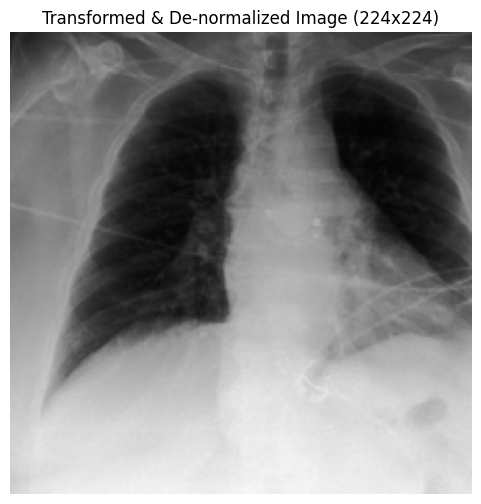

In [12]:
import matplotlib.pyplot as plt

# Reconstruct unnormalized [0, 1] RGB image
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

visual = (processed * std + mean).clamp(0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(visual.permute(1, 2, 0).numpy())
plt.title("Transformed & De-normalized Image (224x224)")
plt.axis("off")
plt.show()

In [13]:
%%writefile /content/DP-MMFL/src/dp_mmfl/data/image_transforms.py
from torchvision import transforms

IMAGE_SIZE = 224
RESIZE_SIZE = 256

def get_train_transforms():
    """
    Image transformations used during model training.
    Preserves anatomical laterality by omitting horizontal flips as spatial positions are important for x-ryas.
    """
    return transforms.Compose([
        transforms.Resize(RESIZE_SIZE, antialias=True),
        transforms.RandomCrop(IMAGE_SIZE),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

def get_eval_transforms():
    """
    Deterministic transformations used for validation and evaluation.
    """
    return transforms.Compose([
        transforms.Resize(RESIZE_SIZE, antialias=True),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

Overwriting /content/DP-MMFL/src/dp_mmfl/data/image_transforms.py


In [14]:
%cd /content/DP-MMFL
!git add src/dp_mmfl/data/image_transforms.py
!git commit -m "added image transformation module"
!git push origin main

/content/DP-MMFL
[main d3f81a4] added image transformation module
 1 file changed, 35 insertions(+)
 create mode 100644 src/dp_mmfl/data/image_transforms.py
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (6/6), 845 bytes | 845.00 KiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/PreethamHD/DP-MMFL.git
   7a7d636..d3f81a4  main -> main
